## Install Dependencies

In [1]:
!uv pip install syftbox-enclave syft-rds==0.1.1-dev.5

Resolved 65 packages in 1.62s                                        
Prepared 3 packages in 1.82s                                             
Installed 38 packages in 198ms                              
 + annotated-types==0.7.0
 + bracex==2.6
 + click==8.2.1
 + contourpy==1.3.3
 + cryptography==45.0.6
 + cycler==0.12.1
 + dnspython==2.7.0
 + email-validator==2.2.0
 + fonttools==4.59.0
 + ipywidgets==8.1.7
 + jupyterlab-widgets==3.0.15
 + kiwisolver==1.4.9
 + loguru==0.7.3
 + markdown-it-py==4.0.0
 + matplotlib==3.10.5
 + mdurl==0.1.2
 + nh3==0.3.0
 + numpy==2.3.2
 + pandas==2.3.1
 + pathspec==0.12.1
 + pillow==11.3.0
 + pydantic==2.11.7
 + pydantic-core==2.33.2
 + pyparsing==3.2.3
 + pytz==2025.2
 + rich==14.1.0
 + shellingham==1.5.4
 + syft-core==0.2.8
 + syft-event==0.2.8
 + syft-rds==0.1.1.dev5
 + syft-rpc==0.2.8
 + syftbox-enclave==0.1.4
 + typer==0.16.0
 + typing-inspection==0.4.1
 + tzdata==2025.2
 + watchdog==6.0.0
 + wcmatch==10.0
 + widgetsnbextension==4.0.14


In [ ]:
# syft
from syft_rds import init_session
from syft_core import Client
from syftbox_enclave import connect

# stdlib
from uuid import uuid4
from pathlib import Path

# Remote Data Science Flow: Organic Coop

This notebook demonstrates a secure data sharing scenario where:

- **Data Owner**: Farmer
- **Data Scientist**: Organic Coop Head

**Dataset**: Contains the Organic Crop Stock Data which is uploaded by the farmers

**Use Case**: The Organic Coop Head would like to run statistical queries on the data uploaded by the farmers in a privacy preserving manner

---
# 0. Both department install SyftBox on their premise & the syft-rds app

Nothing here to show.

---
# 1. Farmer Uploads Data

The Farmers could either:

1. 

    - a dataset containing organic crop data  
    - a mock counterpart  
    - a data card explaining the schema and data collection  

or  

2. Connect to their existing online store (ex: Shopify , Square API) 

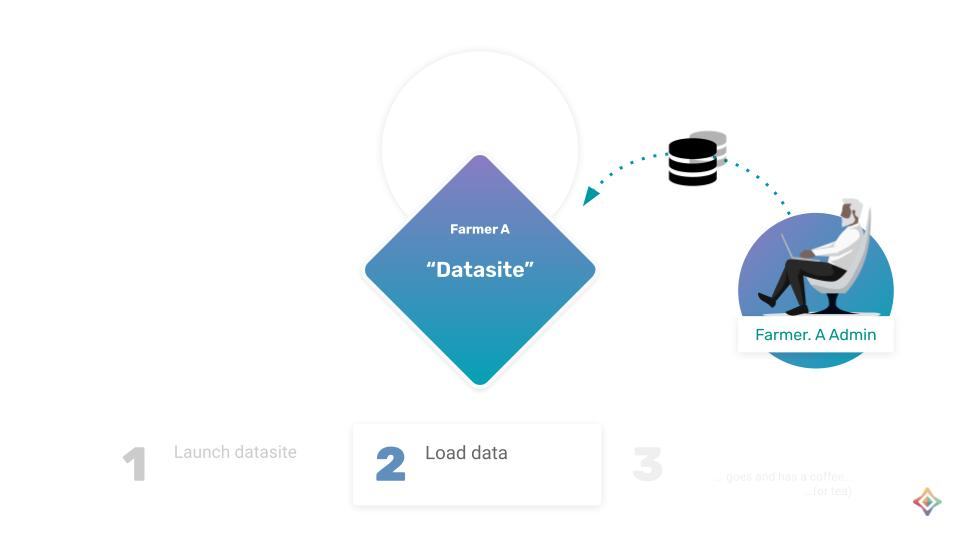

---
# 2. Researcher from Organic Coop accesses the dataset

Researcher can view available datasets and access mock data for development and testing of their analysis code.

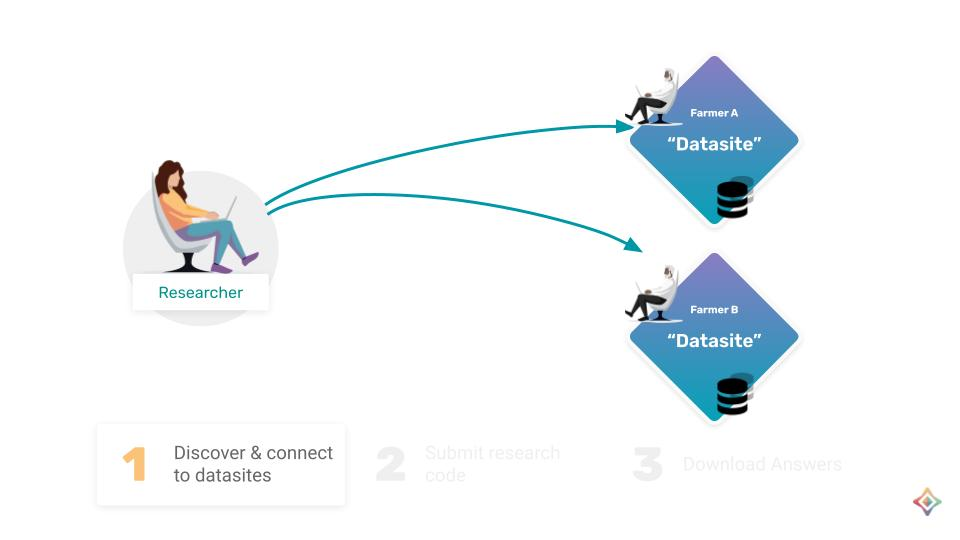

In [3]:
DATA_OWNERS = [
            "rasswanth@openmined.org"
              ]
DATA_SCIENTIST = [ Client.load().email ]

In [4]:
ds_clients = []

for do in DATA_OWNERS:
    ds_client = init_session(do)
    ds_clients.append(ds_client)
    print(f"Logged into {ds_client.host}")


Logged into rasswanth@openmined.org


We collect the datasets from the datasites and inspect one of the dataset.

In [5]:
datasets = [ds_client.datasets[0] for ds_client in ds_clients]    

In [7]:
datasets[0].describe()

uid,9637ccb5-4f6b-4d8f-9462-08ab1ffac427
created_at,2025-07-18 14:54:45
updated_at,2025-07-22 11:47:48
name,Organic Crop Stock Data
readme_path,/Users/rasswanths/SyftBox/datasites/rasswanth@openmined.org/public/datasets/Organic Crop Stock Data/dummy_description.txt
mock_path,/Users/rasswanths/SyftBox/datasites/rasswanth@openmined.org/public/datasets/Organic Crop Stock Data
private_path,/Users/rasswanths/SyftBox/datasites/rasswanth@openmined.org/private/datasets/Organic Crop Stock Data


### How can you write code against data you cannot see?



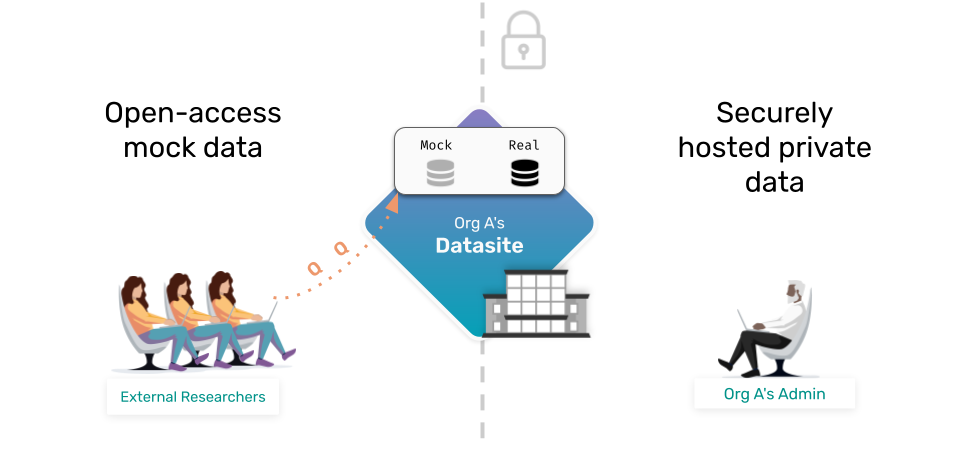

### Propose analysis

In [ ]:
code_path = Path(".") / "code"
code_path.mkdir(exist_ok=True)

code_file_name  = "crop_analysis.py"
code_file_path = code_path / code_file_name

In [ ]:
%%writefile {code_file_path}

import os
from pathlib import Path
from sys import exit

import pandas as pd

DATA_DIR = os.environ["DATA_DIR"]
OUTPUT_DIR = os.environ["OUTPUT_DIR"]

dataset_paths = [Path(dataset_path) for dataset_path in DATA_DIR.split(",")]
csv_paths = []
for dataset_path in dataset_paths:
    csv_paths.extend(list(Path(dataset_path).glob("*.csv")))

total_carrots = 0
total_tomatoes = 0

for csv_path in csv_paths:
    if not csv_path.exists():
        print(f"Warning: CSV path does not exist: {csv_path}")
        exit(1)
    df = pd.read_csv(csv_path)
    total_carrots += df[df["Product name"] == "Carrots"]["Quantity"].sum()
    total_tomatoes += df[df["Product name"] == "Tomatoes"]["Quantity"].sum()

print(f"Total Carrots: {total_carrots}\n")
print(f"Total Tomatoes: {total_tomatoes}\n")

# Create output DataFrame with the same columns as original
output_df = pd.DataFrame({
    "Product name": ["Carrots", "Tomatoes"],
    "Quantity": [total_carrots, total_tomatoes]
})

# Write to CSV
output_csv_path = os.path.join(OUTPUT_DIR, "output.csv")
output_df.to_csv(output_csv_path, index=False)

---
# 3. Researcher submits analysis code

Researcher submits the Analysis code to the Data Owners (Farmers) to be able to run on enclaves

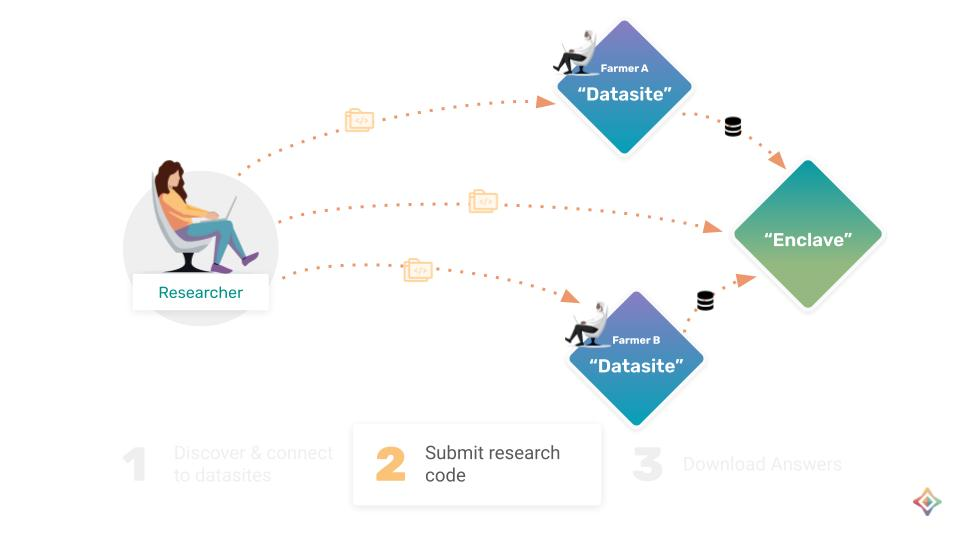

In [ ]:
RANDOM_ID = str(uuid4())[0:8]
ENCLAVE = "enclave-organic-coop@openmined.org"


jobs = []

for ds_client, dataset in zip(ds_clients, datasets):
    job = ds_client.jobs.submit(
                name=f"Test Job - {RANDOM_ID}",
                description="Organic Coop Experiment",
                user_code_path=code_path,
                dataset_name=dataset.name,
                entrypoint = code_file_name,
                enclave = ENCLAVE
            )
    jobs.append(job)

for ds_client in ds_clients:
    ds_client.jobs.get(name=JOB_NAME).describe()

## Submit Enclave Project

In [ ]:
enclave_client = connect(ENCLAVE)

proj_res = enclave_client.create_project(
                   project_name = f"Test Project - {RANDOM_ID}",
                   datasets = datasets,
                   output_owners = DATA_OWNERS + DATA_SCIENTIST,
                   code_path = code_path,
                   entrypoint = code_file_name,
            )

proj_res.status(block=True)

---
# 4. Researcher accesses approved results

After being executed in the enclave, the researcher access the output

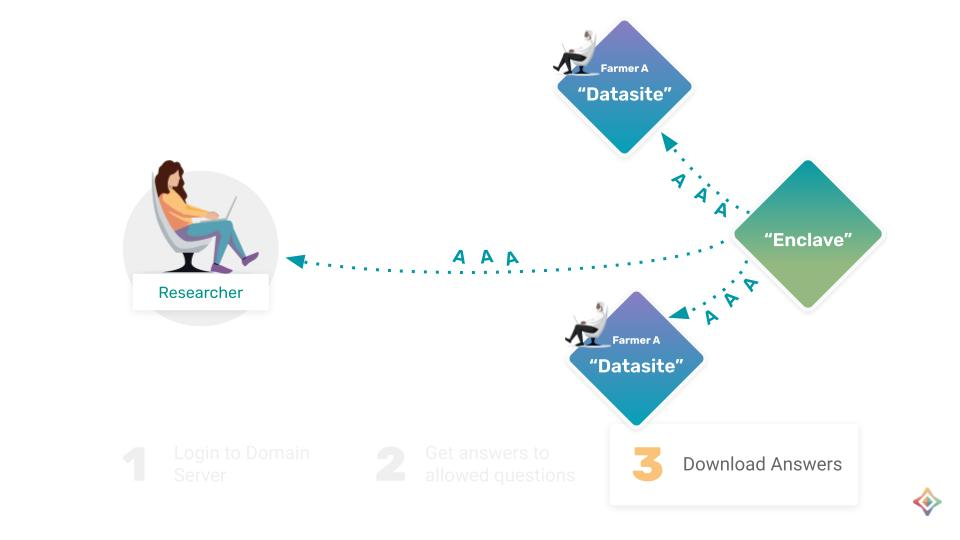

Researcher waits for the execution to finish on the enclave.

In [ ]:
# Wait until the project is ready
proj_res_path = proj_res.output(block=True)

Researcher interprets the result and visualizes it

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# Set the path to the output.csv
output_csv_path = proj_res_path / "output.csv"

# Set up the plotting style
plt.style.use('default')
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Crop Stock Data Analysis', fontsize=16, fontweight='bold')

# Load data
if output_csv_path.exists():
    df = pd.read_csv(output_csv_path)

    # Positions for bars
    x = np.arange(len(df))  # [0, 1, 2, ...]
    width = 0.1

    # Plot bars with fixed width and controlled spacing
    bars = ax.bar(x, df["Quantity"], width=width, color=['#FF6B6B', '#4ECDC4'])

    ax.set_title('Current Stock of Crops by Type', fontweight='bold')
    ax.set_xlabel('Product Name')
    ax.set_ylabel('Quantity')

    # Set x-ticks to product names
    ax.set_xticks(x)
    ax.set_xticklabels(df["Product name"])
    ax.tick_params(axis='x', rotation=0)

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., height + 0.5,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("No crop stock data available to visualize.")

## Success: Research was able to study data belonging to multiple data owners ensuring mutual privacy